# minimal-linop 2/3: What it computes

*Every identity of the algebra, every adjoint of the catalogue and every convention of the README, checked against brute force.*

Series: [1. Why](01_why_linear_operators.ipynb) · [2. What it computes](02_what_it_computes.ipynb) · [3. Benchmark](03_benchmark.ipynb)

In [1]:
import math, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from minimal_linop import (
    LinOp, LinOpIdentity, LinOpMul, LinOpReal, LinOpImag, LinOpSumReduce,
    LinOpMatrix, LinOpFunction, LinOpCat, LinOpFft, LinOpIfft, LinOpFftShift,
    LinOpRoll, LinOpCrop, LinOpPatch, LinOpFlip, LinOpGrad, LinOpDownsample,
    LinOpUpsample, adjoint_error, operator_norm, to_matrix,
)

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.2),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 1.5,
    "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]),
    "image.cmap": "gray",
})
torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.14.0


Two helpers carry the notebook. `check(name, a, b)` prints the largest absolute difference between two tensors, evaluated in complex128, and records it in a table printed at the end; `note` records a result that is not an error. Everything claimed below is checked this way, at float64 precision, so a round-off answer means $10^{-14}$ and not $10^{-6}$.

`dense(op)` is `to_matrix`: the matrix whose column $i$ is the operator applied to the $i$-th basis vector. It is the brute-force reference — it uses only `apply`, never `applyT` — and it is affordable only because everything here is tiny, which is the point of the library.

In [2]:
F64, C64, C128 = torch.float64, torch.complex64, torch.complex128
CHECKS = []


def err(a, b):
    """Largest absolute difference between two tensors, evaluated in complex128."""
    a, b = torch.as_tensor(a).detach().cpu(), torch.as_tensor(b).detach().cpu()
    return (a.to(C128) - b.to(C128)).abs().max().item()


def check(name, a, b, label=None):
    e = err(a, b)
    label = label or str(torch.as_tensor(a).dtype).replace("torch.", "")
    CHECKS.append((name, label, f"{e:.2e}"))
    print(f"{name:<52s} {label:<11s} max|err| = {e:.2e}")


def note(name, label, value):
    CHECKS.append((name, label, str(value)))
    print(f"{name:<52s} {label:<11s} {value}")


def dense(op, in_shape=None, dtype=C128):
    return to_matrix(op, in_shape=in_shape, dtype=dtype)


rand = lambda *s: torch.randn(*s, dtype=C128)

## 1. What an operator is

A `LinOp` is a pair: `apply(x) = A x` and `applyT(y) = A^H y`, with $A^H$ defined by

$$\langle A x, y\rangle = \langle x, A^H y\rangle \quad \text{for all } x, y,
\qquad \langle u, v\rangle = \sum_i \overline{u_i}\, v_i .$$

For a real operator that is the transpose; for a complex one it is the *conjugate* transpose, which is why the library has no `.T`. Two equivalent ways to verify a pair, and both are used throughout:

* the **dot-product test**, `adjoint_error(A, x, y)` $= \big|\operatorname{Re}\langle Ax, y\rangle - \operatorname{Re}\langle x, A^H y\rangle\big| \,/\, (\lVert Ax\rVert \lVert y\rVert)$, which costs one forward and one adjoint and works at any size;
* the **dense identity** $M(A^H) = M(A)^H$, which is exhaustive but costs $n$ forward applications.

The real part in the first is what makes it work for operators that map complex to real, such as `LinOpReal`.

In [3]:
class Conv1d(LinOp):
    """Circular convolution with a kernel h — the example from the README."""

    def __init__(self, h):
        self.kernel = torch.fft.fft(h)

    def apply(self, x):
        return torch.fft.ifft(torch.fft.fft(x) * self.kernel)

    def applyT(self, y):
        return torch.fft.ifft(torch.fft.fft(y) * self.kernel.conj())


C = Conv1d(rand(8))
note("adjoint_error(Conv1d)", "complex128", f"{adjoint_error(C, rand(8)):.2e}")
check("M(C^H) == M(C)^H", dense(C.H, in_shape=8), dense(C, in_shape=8).conj().T)
check("M(C) is circulant: column 1 == roll(column 0)", dense(C, in_shape=8)[:, 1],
      torch.roll(dense(C, in_shape=8)[:, 0], 1))

# A wrong adjoint (the conjugate forgotten) passes no test:
C_bad = LinOpFunction(C.apply, lambda y: torch.fft.ifft(torch.fft.fft(y) * C.kernel))
note("adjoint_error(Conv1d with a sloppy adjoint)", "complex128", f"{adjoint_error(C_bad, rand(8)):.2e}")

adjoint_error(Conv1d)                                complex128  1.79e-17
M(C^H) == M(C)^H                                     complex128  max|err| = 1.24e-16
M(C) is circulant: column 1 == roll(column 0)        complex128  max|err| = 2.22e-16
adjoint_error(Conv1d with a sloppy adjoint)          complex128  3.18e-02


## 2. The algebra

`@`, `+`, `-`, `*` and `.H` build operators out of operators, and every one of them is an identity on the matrices:

$$M(A B) = M(A)M(B), \quad M(A + B) = M(A) + M(B), \quad M(cA) = c\,M(A), \quad M(A^H) = M(A)^H,$$

$$(AB)^H = B^H A^H, \qquad (A + B)^H = A^H + B^H, \qquad (cA)^H = \overline{c}\,A^H, \qquad (A^H)^H = A .$$

The last one is exact in the strongest sense: `A.H.H is A`, the same object, not a copy.

In [4]:
A = LinOpMatrix(rand(4, 6))
B = LinOpMatrix(rand(6, 5))
D = LinOpMatrix(rand(4, 6))
c = 0.3 - 1.7j
MA, MB, MD = dense(A), dense(B), dense(D)

check("M(A @ B) == M(A) M(B)", dense(A @ B), MA @ MB)
check("M(A + D) == M(A) + M(D)", dense(A + D), MA + MD)
check("M(A - D) == M(A) - M(D)", dense(A - D), MA - MD)
check("M(-A) == -M(A)", dense(-A), -MA)
check("M(c * A) == c M(A)", dense(c * A), c * MA)
check("M(A * c) == c M(A)", dense(A * c), c * MA)
check("M(A^H) == M(A)^H", dense(A.H, in_shape=4), MA.conj().T)
check("(A @ B)^H == B^H @ A^H", dense((A @ B).H, in_shape=4), dense(B.H @ A.H, in_shape=4))
check("(A + D)^H == A^H + D^H", dense((A + D).H, in_shape=4), dense(A.H + D.H, in_shape=4))
check("(c A)^H == conj(c) A^H", dense((c * A).H, in_shape=4), dense(c.conjugate() * A.H, in_shape=4))
check("M(sum([A, D, A])) == 2 M(A) + M(D)", dense(sum([A, D, A])), 2 * MA + MD)
note("A.H.H is A", "identity", A.H.H is A)
note("||A||_2, power iteration vs SVD", "complex128",
     f"{operator_norm(A, rand(6), n_iter=200):.10f} vs {float(torch.linalg.matrix_norm(MA, 2)):.10f}")

M(A @ B) == M(A) M(B)                                complex128  max|err| = 9.93e-16
M(A + D) == M(A) + M(D)                              complex128  max|err| = 0.00e+00
M(A - D) == M(A) - M(D)                              complex128  max|err| = 0.00e+00
M(-A) == -M(A)                                       complex128  max|err| = 0.00e+00
M(c * A) == c M(A)                                   complex128  max|err| = 0.00e+00
M(A * c) == c M(A)                                   complex128  max|err| = 0.00e+00
M(A^H) == M(A)^H                                     complex128  max|err| = 0.00e+00
(A @ B)^H == B^H @ A^H                               complex128  max|err| = 0.00e+00
(A + D)^H == A^H + D^H                               complex128  max|err| = 0.00e+00
(c A)^H == conj(c) A^H                               complex128  max|err| = 0.00e+00
M(sum([A, D, A])) == 2 M(A) + M(D)                   complex128  max|err| = 3.14e-16
A.H.H is A                                           identity    

## 3. Every adjoint of the catalogue

One instance of every operator the library exports, checked with the dot-product test in complex128, on a batch of 3. This is the table `tests/` runs on every commit; the point of reproducing it here is that the numbers, not the promise, are what you should believe.

In [5]:
CATALOGUE = [
    ("LinOpIdentity()", LinOpIdentity(), rand(3, 8), rand(3, 8)),
    ("LinOpMul(c)", LinOpMul(rand(8)), rand(3, 8), rand(3, 8)),
    ("LinOpReal()", LinOpReal(), rand(3, 8), torch.randn(3, 8, dtype=F64)),
    ("LinOpImag()", LinOpImag(), rand(3, 8), torch.randn(3, 8, dtype=F64)),
    ("LinOpSumReduce(-2, 4)", LinOpSumReduce(-2, 4), rand(3, 4, 8), rand(3, 1, 8)),
    ("LinOpMatrix(M)", LinOpMatrix(rand(5, 8)), rand(3, 8), rand(3, 5)),
    ("LinOpFunction(f, fT)", LinOpFunction(lambda x: torch.fft.fft(x, norm="ortho"),
                                           lambda y: torch.fft.ifft(y, norm="ortho")),
     rand(3, 8), rand(3, 8)),
    ("LinOpCat([A0, A1])", LinOpCat([LinOpCrop(8, 4), LinOpCrop(8, 2)]), rand(3, 8), rand(3, 6)),
    ("LinOpFft(norm='backward')", LinOpFft(dim=(-2, -1), norm="backward"), rand(3, 4, 8), rand(3, 4, 8)),
    ("LinOpIfft(norm='forward')", LinOpIfft(norm="forward"), rand(3, 8), rand(3, 8)),
    ("LinOpFftShift((-2, -1))", LinOpFftShift(dim=(-2, -1)), rand(3, 5, 8), rand(3, 5, 8)),
    ("LinOpRoll((2, -3), pad_zeros)", LinOpRoll((2, -3), dim=(-2, -1), pad_zeros=True),
     rand(3, 5, 8), rand(3, 5, 8)),
    ("LinOpCrop(fourier_origin)", LinOpCrop((5, 8), (3, 4), fourier_origin=True), rand(3, 5, 8), rand(3, 3, 4)),
    ("LinOpPatch(shifts=(2, -3))", LinOpPatch((5, 8), (3, 4), shifts=(2, -3)), rand(3, 5, 8), rand(3, 3, 4)),
    ("LinOpFlip((-2, -1))", LinOpFlip(dim=(-2, -1)), rand(3, 5, 8), rand(3, 5, 8)),
    ("LinOpGrad(2)", LinOpGrad(2), rand(3, 5, 8), rand(3, 2, 5, 8)),
    ("LinOpDownsample(3)", LinOpDownsample((5, 8), 3), rand(3, 5, 8), rand(3, 2, 3)),
    ("LinOpUpsample(3)", LinOpUpsample((5, 8), 3), rand(3, 5, 8), rand(3, 15, 24)),
]
try:
    import minimal_fft                                            # optional [fft] extra
    from minimal_linop import LinOpZoomFft
    CATALOGUE.append(("LinOpZoomFft(band)",
                      LinOpZoomFft((5, 8), (4, 6), k_start=-0.4, k_end=0.9), rand(3, 5, 8), rand(3, 4, 6)))
except ImportError:
    print("minimal-fft is not installed: LinOpZoomFft skipped")

print(f"{'operator':<32s}{'shapes':<22s}{'dot-product test':>18s}{'batch axes':>13s}")
worst = 0.0
for name, op, x, y in CATALOGUE:
    e = adjoint_error(op, x, y)
    worst = max(worst, e)
    batched = err(op.apply(x)[0], op.apply(x[0])) < 1e-12
    shapes = f"{op.in_shape or 'any'} -> {op.out_shape or 'any'}"
    print(f"{name:<32s}{shapes:<22s}{e:>18.2e}{'ok' if batched else 'BROKEN':>13s}")
note(f"dot-product test, {len(CATALOGUE)} operators", "complex128", f"worst = {worst:.2e}")

operator                        shapes                  dot-product test   batch axes
LinOpIdentity()                 any -> any                      0.00e+00           ok
LinOpMul(c)                     (8,) -> (8,)                    2.92e-17           ok
LinOpReal()                     any -> any                      0.00e+00           ok
LinOpImag()                     any -> any                      7.84e-17           ok
LinOpSumReduce(-2, 4)           any -> any                      1.47e-17           ok
LinOpMatrix(M)                  (8,) -> (5,)                    1.45e-17           ok
LinOpFunction(f, fT)            any -> any                      1.99e-17           ok
LinOpCat([A0, A1])              (8,) -> (6,)                    0.00e+00           ok
LinOpFft(norm='backward')       any -> any                      1.43e-17           ok
LinOpIfft(norm='forward')       any -> any                      5.57e-17           ok
LinOpFftShift((-2, -1))         any -> any            

The "batch axes" column re-applies each operator to a single element of the batch and compares: operators act on the trailing axes their shapes name and leave every leading axis alone. That is enforced, not just intended — a `dim` counted from the front is rejected at construction, since it would eat a batch axis:

In [6]:
for bad in ("LinOpFft(dim=0)", "LinOpRoll(1, dim=1)", "LinOpSumReduce(dim=0, size=3)"):
    try:
        eval(bad)
        note(bad, "-", "accepted (!)")
    except ValueError as e:
        note(bad, "raises", f"ValueError: {e}")

LinOpFft(dim=0)                                      raises      ValueError: dim must be negative, so that the operator acts on trailing axes; got 0
LinOpRoll(1, dim=1)                                  raises      ValueError: dim must be negative, so that the operator acts on trailing axes; got 1
LinOpSumReduce(dim=0, size=3)                        raises      ValueError: dim must be negative, so that the operator acts on trailing axes; got 0


## 4. The operators, as pictures

`to_matrix(A)` is also the fastest way to *see* what an operator does. Below, the real part of the dense matrix of eight of them (red positive, blue negative, white zero), each column being one basis vector transformed. A permutation — roll, fftshift — has a single entry per column; a crop is a rectangular slice of the identity, and `fourier_origin` takes that slice from the two corners instead of the middle; the FFT is dense, and its real part is the cosine table; `LinOpGrad` is bidiagonal, $+1$ above $-1$, with the zero last row that makes its boundary condition; `LinOpPatch` is the crop composed with the roll, wrapped around.

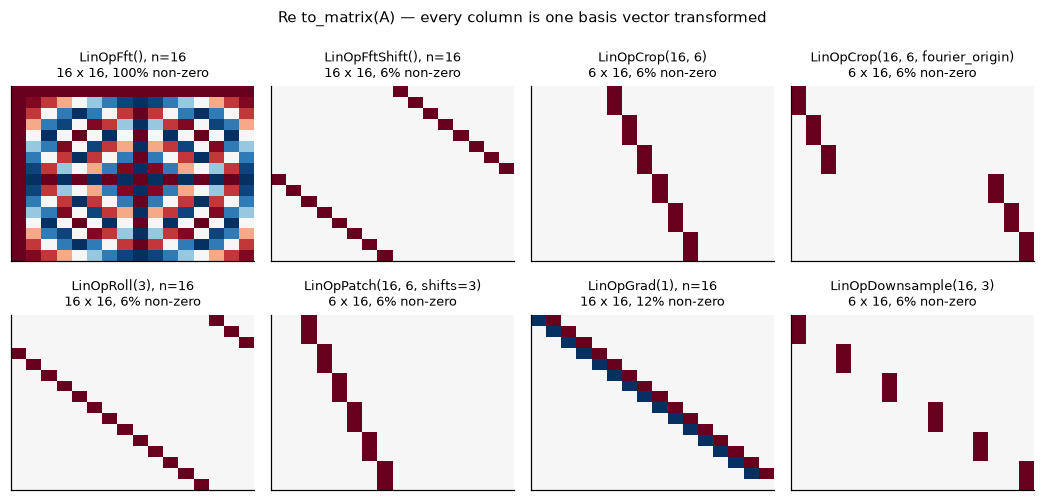

M(Patch) == M(Crop @ Roll)                           complex128  max|err| = 0.00e+00
M(Fft) is the DFT matrix / sqrt(n)                   complex128  max|err| = 1.45e-15


In [7]:
gallery = [
    ("LinOpFft(), n=16", LinOpFft(), 16),
    ("LinOpFftShift(), n=16", LinOpFftShift(), 16),
    ("LinOpCrop(16, 6)", LinOpCrop(16, 6), 16),
    ("LinOpCrop(16, 6, fourier_origin)", LinOpCrop(16, 6, fourier_origin=True), 16),
    ("LinOpRoll(3), n=16", LinOpRoll(3), 16),
    ("LinOpPatch(16, 6, shifts=3)", LinOpPatch(16, 6, shifts=3), 16),
    ("LinOpGrad(1), n=16", LinOpGrad(1), 16),
    ("LinOpDownsample(16, 3)", LinOpDownsample(16, 3), 16),
]
fig, axes = plt.subplots(2, 4, figsize=(9.6, 4.6))
for ax, (name, op, n) in zip(axes.ravel(), gallery):
    M = dense(op, in_shape=n).numpy()
    lim = max(abs(M.real).max(), 1e-12)
    ax.imshow(M.real, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto", interpolation="nearest")
    ax.set_title(f"{name}\n{M.shape[0]} x {M.shape[1]}, {100*(abs(M) > 1e-12).mean():.0f}% non-zero",
                 fontsize=8.5)
    ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Re to_matrix(A) — every column is one basis vector transformed", fontsize=10)
fig.tight_layout()
plt.show()

check("M(Patch) == M(Crop @ Roll)", dense(LinOpPatch(16, 6, shifts=3), in_shape=16),
      dense(LinOpCrop(16, 6) @ LinOpRoll(3), in_shape=16))
check("M(Fft) is the DFT matrix / sqrt(n)",
      dense(LinOpFft(), in_shape=8),
      torch.exp(-2j * math.pi * torch.outer(torch.arange(8, dtype=F64), torch.arange(8, dtype=F64)) / 8)
      / math.sqrt(8))

## 5. Shapes

`in_shape` and `out_shape` describe the **trailing** axes an operator acts on. `None` means shape-agnostic — an FFT works on any length — and is compatible with everything; sums and compositions check the declared shapes at construction, so a mistake in a forward model is caught when the model is built rather than when it is run.

A composition fills a shape the shape-agnostic side does not declare from the other side. That assumes it preserves shape, which `LinOpFft` does and `LinOpGrad` (which adds a channel axis), `LinOpSumReduce` and a multi-operator `LinOpCat` do not; those say so with `preserves_shape = False`, and the composition then leaves the shape unknown rather than declaring a wrong one.

In [8]:
model = LinOpFft(dim=(-2, -1)) @ LinOpMul(rand(8, 8)) @ LinOpCrop((32, 32), (8, 8))
note("shapes of F @ Mul @ Crop", "inferred", f"{model.in_shape} -> {model.out_shape}")

try:
    LinOpMul(rand(4, 4)) @ LinOpCrop((32, 32), (8, 8))
except ValueError as e:
    note("mismatched composition", "raises", f"ValueError: {e}")

grad_chain = LinOpGrad(2) @ LinOpCrop((32, 32), (8, 8))
note("shapes of Grad @ Crop", "inferred",
     f"{grad_chain.in_shape} -> {grad_chain.out_shape} (not (8, 8): Grad adds an axis)")
note("actual output shape", "computed", tuple(grad_chain.apply(rand(32, 32)).shape))
note("LinOpMul(c) with c.shape = (1, 8)", "declares", LinOpMul(rand(1, 8)).in_shape)
note("LinOpMul(c) with c.shape = (4, 8)", "declares", LinOpMul(rand(4, 8)).in_shape)

cat = LinOpCat([LinOpCrop((8, 8), (8, 4)), LinOpCrop((8, 8), (8, 2))])
note("LinOpCat splits the adjoint by out_shape", "widths", f"{cat.out_shape} = 4 + 2 columns")
y_cat = rand(8, 6)
check("Cat^H y == sum of the pieces", cat.applyT(y_cat),
      cat.ops[0].applyT(y_cat[..., :4]) + cat.ops[1].applyT(y_cat[..., 4:]))

try:
    cat.applyT(rand(8, 7))
except ValueError as e:
    note("a y of the wrong width", "raises", f"ValueError: {e}")

shapes of F @ Mul @ Crop                             inferred    (32, 32) -> (8, 8)
mismatched composition                               raises      ValueError: incompatible shapes in A @ B (B.out_shape vs A.in_shape): (8, 8) vs (4, 4)
shapes of Grad @ Crop                                inferred    (32, 32) -> None (not (8, 8): Grad adds an axis)
actual output shape                                  computed    (2, 8, 8)
LinOpMul(c) with c.shape = (1, 8)                    declares    None
LinOpMul(c) with c.shape = (4, 8)                    declares    (4, 8)
LinOpCat splits the adjoint by out_shape             widths      (8, 6) = 4 + 2 columns
Cat^H y == sum of the pieces                         complex128  max|err| = 0.00e+00
a y of the wrong width                               raises      ValueError: LinOpCat splits its adjoint input into widths [4, 2] (total 6), but got 7 columns


## 6. The FFT normalisations

With $W$ the unnormalised DFT matrix over the transformed axes and $N$ the product of their lengths, `torch.fft` offers three scalings:

| `norm` | forward | inverse |
|---|---|---|
| `"backward"` (torch's default) | $W$ | $W^H/N$ |
| `"ortho"` (**this library's default**) | $W/\sqrt{N}$ | $W^H/\sqrt{N}$ |
| `"forward"` | $W/N$ | $W^H$ |

The adjoint of a transform is therefore the *opposite* transform with the *conjugate* norm (`backward` $\leftrightarrow$ `forward`, `ortho` $\leftrightarrow$ `ortho`), which is what `LinOpFft.applyT` does. Only `"ortho"` is unitary, and only then is $A^H = A^{-1}$: with the other norms the adjoint is still exact, but it is not the inverse — $A^H A$ is $N I$ for `"backward"` and $I/N$ for `"forward"`, which is what the two residuals $N - 1 = 7$ and $1 - 1/N = 0.875$ below say. A solver that takes the inverse for the adjoint is wrong by exactly that factor.

In [9]:
n = 8
for norm in ("ortho", "backward", "forward", None):
    Aq = LinOpFft(norm=norm)
    M = dense(Aq, in_shape=n)
    check(f"norm={norm!r:<11s} M(A^H) == M(A)^H", dense(Aq.H, in_shape=n), M.conj().T)
    note(f"norm={norm!r:<11s} ||A^H A - I||", "complex128",
         f"{(M.conj().T @ M - torch.eye(n, dtype=C128)).abs().max().item():.2e}"
         + ("   <- unitary" if norm == "ortho" else ""))

xq = rand(3, 4, 8)
check("LinOpFft(dim=(-2,-1)) == torch.fft.fft2(ortho)", LinOpFft(dim=(-2, -1)).apply(xq),
      torch.fft.fft2(xq, norm="ortho"))
check("LinOpIfft().apply == LinOpFft().applyT (ortho)", LinOpIfft().apply(xq), LinOpFft().applyT(xq))
check("LinOpFftShift^H == ifftshift", LinOpFftShift(dim=(-2, -1)).applyT(xq),
      torch.fft.ifftshift(xq, dim=(-2, -1)))

norm='ortho'     M(A^H) == M(A)^H                    complex128  max|err| = 0.00e+00
norm='ortho'     ||A^H A - I||                       complex128  1.11e-16   <- unitary
norm='backward'  M(A^H) == M(A)^H                    complex128  max|err| = 0.00e+00
norm='backward'  ||A^H A - I||                       complex128  7.00e+00
norm='forward'   M(A^H) == M(A)^H                    complex128  max|err| = 0.00e+00
norm='forward'   ||A^H A - I||                       complex128  8.75e-01
norm=None        M(A^H) == M(A)^H                    complex128  max|err| = 0.00e+00
norm=None        ||A^H A - I||                       complex128  7.00e+00
LinOpFft(dim=(-2,-1)) == torch.fft.fft2(ortho)       complex128  max|err| = 0.00e+00
LinOpIfft().apply == LinOpFft().applyT (ortho)       complex128  max|err| = 0.00e+00
LinOpFftShift^H == ifftshift                         complex128  max|err| = 0.00e+00


## 7. Where the origin is

Two conventions decide what "the middle" means, and both follow `torch`:

* **`LinOpCrop`** keeps the indices `in//2 - out//2` onwards, the same centring as `fftshift`, so that cropping and zero-padding round-trip: `crop(pad(y)) == y` for any parities.
* **`fourier_origin=True`** instead keeps the *corners* — the low frequencies of a spectrum whose DC term sits at index 0 — dropping the high frequencies in the middle.

`LinOpRoll` shifts circularly (`pad_zeros=True` zeroes what wrapped instead), and `LinOpPatch` is exactly `LinOpCrop @ LinOpRoll` with both options, computed in $O(\text{patch})$.

In [10]:
v = torch.arange(9, dtype=F64)
note("crop 9 -> 4 keeps indices 9//2-4//2 = 2 ...", "values", LinOpCrop(9, 4).apply(v).tolist())
note("crop 8 -> 3 keeps indices 8//2-3//2 = 3 ...", "values", LinOpCrop(8, 3).apply(v[:8]).tolist())
note("fourier_origin keeps the corners", "values",
     LinOpCrop(8, 4, fourier_origin=True).apply(v[:8]).tolist())
check("crop(pad(y)) == y  (crop is a projection)", LinOpCrop(9, 4).apply(LinOpCrop(9, 4).applyT(v[:4])), v[:4])
note("roll(+1)", "values", LinOpRoll(1).apply(v[:4]).tolist())
note("roll(+1, pad_zeros=True)", "values", LinOpRoll(1, pad_zeros=True).apply(v[:4]).tolist())

for shift in (0, 3, -4, 11):
    for pad in (False, True):
        for fo in (False, True):
            ref = LinOpCrop((9, 8), (4, 3), fourier_origin=fo) @ LinOpRoll((shift, -shift), dim=(-2, -1), pad_zeros=pad)
            pat = LinOpPatch((9, 8), (4, 3), shifts=(shift, -shift), pad_zeros=pad, fourier_origin=fo)
            xf = rand(2, 9, 8)
            assert torch.equal(pat.apply(xf), ref.apply(xf))
            yf = rand(2, 4, 3)
            assert torch.equal(pat.applyT(yf), ref.applyT(yf))
note("Patch == Crop @ Roll, 16 combinations", "exact", "bit-identical, both directions")

check("Grad: forward differences, zero last row", LinOpGrad(1).apply(v)[0],
      torch.cat([v[1:] - v[:-1], torch.zeros(1)]))
check("Grad^H is the negative divergence", LinOpGrad(1).applyT(LinOpGrad(1).apply(v))[1:-1],
      (-(v[2:] - 2 * v[1:-1] + v[:-2])))
check("Downsample keeps every 3rd sample", LinOpDownsample(9, 3).apply(v), v[::3])
check("Upsample^H sums each block", LinOpUpsample(3, 3).applyT(v), v.reshape(3, 3).sum(-1))
check("Flip is self-adjoint", dense(LinOpFlip(), in_shape=6),
      dense(LinOpFlip(), in_shape=6).conj().T)

crop 9 -> 4 keeps indices 9//2-4//2 = 2 ...          values      [2.0, 3.0, 4.0, 5.0]
crop 8 -> 3 keeps indices 8//2-3//2 = 3 ...          values      [3.0, 4.0, 5.0]
fourier_origin keeps the corners                     values      [0.0, 1.0, 6.0, 7.0]
crop(pad(y)) == y  (crop is a projection)            float64     max|err| = 0.00e+00
roll(+1)                                             values      [3.0, 0.0, 1.0, 2.0]
roll(+1, pad_zeros=True)                             values      [0.0, 0.0, 1.0, 2.0]


Patch == Crop @ Roll, 16 combinations                exact       bit-identical, both directions
Grad: forward differences, zero last row             float64     max|err| = 0.00e+00
Grad^H is the negative divergence                    float64     max|err| = 0.00e+00
Downsample keeps every 3rd sample                    float64     max|err| = 0.00e+00
Upsample^H sums each block                           float64     max|err| = 0.00e+00
Flip is self-adjoint                                 complex128  max|err| = 0.00e+00


## 8. Autograd, `vmap`, `jacrev`

The operators are plain out-of-place tensor code, so they compose with everything in `torch`: reverse-mode autograd through the forward *and* the adjoint, `torch.func.vmap` over a batch axis, `torch.func.jacrev` for a Jacobian. `gradcheck` compares the analytic Wirtinger derivatives with central differences in complex128 and is the definitive test.

In [11]:
op = LinOpFft(dim=(-2, -1)) @ LinOpMul(rand(4, 4)) @ LinOpPatch((6, 6), (4, 4), shifts=(1, -2))

xg = rand(6, 6).requires_grad_(True)
note("gradcheck through apply", "complex128",
     torch.autograd.gradcheck(lambda t: op.apply(t), (xg,)))
yg = rand(4, 4).requires_grad_(True)
note("gradcheck through applyT", "complex128",
     torch.autograd.gradcheck(lambda t: op.applyT(t), (yg,)))

xb, yb = rand(5, 6, 6), rand(5, 4, 4)
check("vmap(op.apply) == op.apply on the batch", torch.func.vmap(op.apply)(xb), op.apply(xb))
check("vmap(op.applyT) == op.applyT on the batch", torch.func.vmap(op.applyT)(yb), op.applyT(yb))

# The Jacobian of a real-valued function of a phase, straight through the operator.
J = torch.func.jacrev(lambda p: (op.apply(torch.exp(1j * p)).abs() ** 2))(torch.randn(6, 6, dtype=F64))
note("jacrev of |A e^{i phi}|^2 w.r.t. phi", "float64", f"shape {tuple(J.shape)}, finite: {bool(torch.isfinite(J).all())}")

# The gradient of the least-squares loss, again: autograd and the adjoint agree.
x0, b0 = rand(6, 6).requires_grad_(True), rand(4, 4)
(0.5 * (op.apply(x0) - b0).abs().pow(2).sum()).backward()
check("autograd grad == A^H (A x - b)", x0.grad, op.applyT(op.apply(x0.detach()) - b0))

gradcheck through apply                              complex128  True
gradcheck through applyT                             complex128  True
vmap(op.apply) == op.apply on the batch              complex128  max|err| = 0.00e+00
vmap(op.applyT) == op.applyT on the batch            complex128  max|err| = 0.00e+00


jacrev of |A e^{i phi}|^2 w.r.t. phi                 float64     shape (4, 4, 6, 6), finite: True
autograd grad == A^H (A x - b)                       complex128  max|err| = 2.50e-16


## 9. `LinOpZoomFft`, the one optional operator

`pip install "minimal-linop[fft]"` adds [minimal-fft](https://github.com/jon-dong/minimal-fft) and with it `LinOpZoomFft`, the chirp-Z transform on an arbitrary frequency band: the spectrum where you want it, at the sampling you want, without padding to a huge grid. Its adjoint is the zoomed inverse transform with the conjugate norm, exact on any band. With the default band it is the plain FFT.

In [12]:
try:
    import minimal_fft
    from minimal_linop import LinOpZoomFft

    Z, xz = LinOpZoomFft((8, 8)), rand(2, 8, 8)
    check("LinOpZoomFft default band == LinOpFft", Z.apply(xz), LinOpFft(dim=(-2, -1)).apply(xz))

    Zb = LinOpZoomFft((9, 12), (5, 7), k_start=-0.4, k_end=0.9, center=True, include_end=True)
    note("zoomed band 9x12 -> 5x7, dot-product test", "complex128",
         f"{adjoint_error(Zb, rand(9, 12), rand(5, 7)):.2e}")
    check("M(Z^H) == M(Z)^H on the band", dense(Zb.H, in_shape=(5, 7)), dense(Zb, in_shape=(9, 12)).conj().T)
    chain = Zb @ LinOpMul(rand(9, 12))
    note("composes like any other operator", "complex128",
         f"{chain.in_shape} -> {chain.out_shape}, adjoint_error {adjoint_error(chain, rand(9, 12), rand(5, 7)):.2e}")
except ImportError:
    note("LinOpZoomFft", "-", "minimal-fft is not installed")

LinOpZoomFft default band == LinOpFft                complex128  max|err| = 2.68e-15
zoomed band 9x12 -> 5x7, dot-product test            complex128  1.76e-16
M(Z^H) == M(Z)^H on the band                         complex128  max|err| = 6.09e-16
composes like any other operator                     complex128  (9, 12) -> (5, 7), adjoint_error 1.63e-16


## 10. Devices

Nothing in the library holds a device: the index tables and masks are built on the device of the tensor handed to it (`LinOpPatch` caches one set per device), and the coefficients you pass in decide where they live. The same operator therefore runs wherever `torch` runs. Below, MPS against the CPU in complex64 when Metal is available.

In [13]:
if torch.backends.mps.is_available():
    try:
        probe_c = torch.randn(16, 16, dtype=C64)
        op_cpu = LinOpFft(dim=(-2, -1)) @ LinOpMul(probe_c) @ LinOpPatch((64, 64), (16, 16), shifts=(5, -7))
        op_mps = LinOpFft(dim=(-2, -1)) @ LinOpMul(probe_c.to("mps")) @ LinOpPatch((64, 64), (16, 16), shifts=(5, -7))
        xc = torch.randn(4, 64, 64, dtype=C64)
        check("MPS vs CPU, apply", op_mps.apply(xc.to("mps")).cpu(), op_cpu.apply(xc), label="complex64")
        yc = torch.randn(4, 16, 16, dtype=C64)
        check("MPS vs CPU, applyT", op_mps.applyT(yc.to("mps")).cpu(), op_cpu.applyT(yc), label="complex64")
        note("adjoint_error on MPS", "complex64",
             f"{adjoint_error(op_mps, xc.to('mps'), yc.to('mps')):.2e}")
        note("output device", "-", op_mps.apply(xc.to("mps")).device)
    except Exception as exc:                       # pragma: no cover - device dependent
        note("MPS", "-", f"{type(exc).__name__}: {exc}")
else:
    note("MPS", "-", "not available on this machine")

MPS vs CPU, apply                                    complex64   max|err| = 3.37e-07
MPS vs CPU, applyT                                   complex64   max|err| = 5.96e-07
adjoint_error on MPS                                 complex64   7.67e-09
output device                                        -           mps:0


## Summary

In [14]:
width = max(len(n) for n, _, _ in CHECKS)
print(f"{'check':<{width}s}  {'dtype':<11s}  result")
print("-" * (width + 40))
for name, label, value in CHECKS:
    print(f"{name:<{width}s}  {label:<11s}  {value}")
print("-" * (width + 40))
print(f"{len(CHECKS)} checks recorded")

check                                           dtype        result
--------------------------------------------------------------------------------------
adjoint_error(Conv1d)                           complex128   1.79e-17
M(C^H) == M(C)^H                                complex128   1.24e-16
M(C) is circulant: column 1 == roll(column 0)   complex128   2.22e-16
adjoint_error(Conv1d with a sloppy adjoint)     complex128   3.18e-02
M(A @ B) == M(A) M(B)                           complex128   9.93e-16
M(A + D) == M(A) + M(D)                         complex128   0.00e+00
M(A - D) == M(A) - M(D)                         complex128   0.00e+00
M(-A) == -M(A)                                  complex128   0.00e+00
M(c * A) == c M(A)                              complex128   0.00e+00
M(A * c) == c M(A)                              complex128   0.00e+00
M(A^H) == M(A)^H                                complex128   0.00e+00
(A @ B)^H == B^H @ A^H                          complex128   0.00e+00
(A + 

Everything above is an identity, not a demonstration: the algebra is exact on the matrices, every adjoint of the catalogue passes the dot-product test at float64 round-off, the shape rules are enforced at construction, and the FFT conventions are `torch`'s with `norm="ortho"` as the default. The same checks live in `tests/`, run against brute force, so the README cannot drift from the code.

**Next.** [Notebook 3](03_benchmark.ipynb) measures the price of the abstraction: how much a composed operator costs against the same lines written by hand, how `LinOpPatch` scales against `LinOpCrop @ LinOpRoll` as the object grows, batching, the cost of `to_matrix`, CPU against MPS, the precision of the adjoint in float32 and float64 — and when not to use any of this.